# LIB 

In [142]:
import numpy as np
from astropy.io import fits
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

import csv

import pandas as pd
import os

import numpy as np

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.visualization import ZScaleInterval

from scipy.ndimage import zoom
from scipy.interpolate import griddata
import scipy
from scipy.optimize import curve_fit
from scipy.stats import norm

from functions import common_elem, pol_vec_components,  gaussian, polang_map
# import functions_G111
import functions

from reproject import reproject_interp


# Func

In [236]:
def structure_function_QU_old(Q, U, R_list, *,
                          min_pI=None,
                          bin_width=0.5,
                          max_pairs=None,
                          random_seed=0):
    """
    Compute polarization-angle structure function D_phi(R) from Q,U maps.

    Parameters
    ----------
    Q, U : 2D np.ndarray
        Stokes Q and U maps, same shape (Ny, Nx).
    R_list : array-like
        Radii (pixel separations) at which to compute the structure function.
        Can be ints or floats (in pixels).
    min_pI : float or None
        Optional threshold on polarized intensity pI = sqrt(Q^2+U^2).
        Pixels with pI < min_pI are masked out.
        If None, no threshold besides finite values.
    bin_width : float
        Radial bin half-width in pixels. Pairs with distance d satisfying
        |d - R| <= bin_width are included for that R.
    max_pairs : int or None
        If set, randomly subsample at most this many valid pairs per R
        to reduce compute cost on large maps.
    random_seed : int
        RNG seed for subsampling.

    Returns
    -------
    out : dict
        Keys:
          'R'      : np.ndarray of R values (same order as input)
          'Dphi'   : np.ndarray of D_phi(R)
          'Npairs' : np.ndarray of number of pairs used per R
    """
    Q = np.asarray(Q, dtype=float)
    U = np.asarray(U, dtype=float)
    if Q.shape != U.shape or Q.ndim != 2:
        raise ValueError("Q and U must be 2D arrays with the same shape.")

    Ny, Nx = Q.shape

    # Polarized intensity and normalized Stokes
    pI = np.sqrt(Q*Q + U*U)

    valid = np.isfinite(Q) & np.isfinite(U) & np.isfinite(pI) & (pI > 0)
    if min_pI is not None:
        valid &= (pI >= float(min_pI))

    # Normalized Stokes: q = Q/pI, u = U/pI
    q = np.full_like(Q, np.nan, dtype=float)
    u = np.full_like(U, np.nan, dtype=float)
    q[valid] = Q[valid] / pI[valid]
    u[valid] = U[valid] / pI[valid]

    R_arr = np.asarray(R_list, dtype=float)
    Dphi = np.full_like(R_arr, np.nan, dtype=float)
    Npairs = np.zeros_like(R_arr, dtype=int)

    rng = np.random.default_rng(random_seed)

    # Precompute coordinate grids for valid pixels
    y_idx, x_idx = np.where(valid)
    n_valid = len(y_idx)
    if n_valid < 2:
        raise ValueError("Not enough valid pixels to compute structure function.")
   
    
    
    # def accumulate_shift(dy, dx):
    #     # Перекрытие в координатах q/u (первой карты)
    #     y0 = max(0, -dy)
    #     y1 = min(Ny, Ny - dy)   # гарантирует, что y1+dy <= Ny
    
    #     x0 = max(0, -dx)
    #     x1 = min(Nx, Nx - dx)   # гарантирует, что x1+dx <= Nx
    
    #     # Если перекрытия нет
    #     if (y1 <= y0) or (x1 <= x0):
    #         return None
    
    #     q1 = q[y0:y1, x0:x1]
    #     u1 = u[y0:y1, x0:x1]
    #     q2 = q[y0+dy:y1+dy, x0+dx:x1+dx]
    #     u2 = u[y0+dy:y1+dy, x0+dx:x1+dx]
    
    #     # На время отладки полезно:
    #     # assert q1.shape == q2.shape == u1.shape == u2.shape, (dy, dx, q1.shape, q2.shape)
    
    #     m = np.isfinite(q1) & np.isfinite(u1) & np.isfinite(q2) & np.isfinite(u2)
    #     if not np.any(m):
    #         return None
    
    #     dq = q1[m] - q2[m]
    #     du = u1[m] - u2[m]
    #     return 0.25 * (dq*dq + du*du)

    # Helper to accumulate pair contributions for a given integer shift (dy, dx)
    def accumulate_shift(dy, dx):
        # Overlapping slices for shift (dy, dx)
        y1s = slice(max(0, dy), min(Ny, Ny + dy))
        y2s = slice(max(0, -dy), min(Ny, Ny - dy))
        x1s = slice(max(0, dx), min(Nx, Nx + dx))
        x2s = slice(max(0, -dx), min(Nx, Nx - dx))
        q1 = q[y1s, x1s]; u1 = u[y1s, x1s]
        q2 = q[y2s, x2s]; u2 = u[y2s, x2s]
        # print('q1.shape',q1.shape)
        # print('q2.shape',q2.shape)
        
        # print('u1.shape',u1.shape)
        # print('u2.shape',u2.shape)
        
        m = np.isfinite(q1) & np.isfinite(u1) & np.isfinite(q2) & np.isfinite(u2)
        if not np.any(m):
            return None  # no pairs

        dq = (q1[m] - q2[m])
        du = (u1[m] - u2[m])
        # D_phi contribution per pair:
        # 1/4 * (dq^2 + du^2)
        contrib = 0.25 * (dq*dq + du*du)
        print('contrib',contrib)
        return contrib

    # For each R, build all integer shifts (dx,dy) whose distance falls in the bin
    for i, R in enumerate(R_arr):
        if R < 0:
            continue

        # Search shifts in a square that covers the ring
        rmax = int(np.ceil(R + bin_width))
        shifts = []
        for dy in range(-rmax, rmax + 1):
            for dx in range(-rmax, rmax + 1):
                if dx == 0 and dy == 0:
                    continue
                d = np.hypot(dx, dy)
                if abs(d - R) <= bin_width:
                    shifts.append((dy, dx))

        if len(shifts) == 0:
            continue

        all_contrib = []
        for dy, dx in shifts:
            contrib = accumulate_shift(dy, dx)
            if contrib is not None and contrib.size > 0:
                all_contrib.append(contrib)

        if len(all_contrib) == 0:
            continue

        contrib_vec = np.concatenate(all_contrib)
        n = contrib_vec.size

        if (max_pairs is not None) and (n > max_pairs):
            idx = rng.choice(n, size=int(max_pairs), replace=False)
            contrib_vec = contrib_vec[idx]
            n = contrib_vec.size
        print('n',n)
        Dphi[i] = np.nanmean(contrib_vec)
        Npairs[i] = n

    return {"R": R_arr, "Dphi": Dphi, "Npairs": Npairs}


# --------------------
# Example usage:
# --------------------
# Q, U are 2D arrays (Ny, Nx)
# R_list = np.arange(1, 51)  # radii in pixels
# out = structure_function_QU(Q, U, R_list, min_pI=3.0, bin_width=0.5, max_pairs=200000)
# print(out["R"])
# print(out["Dphi"])
# print(out["Npairs"])

In [98]:
import numpy as np

def structure_function_QU(Q, U, R_list, *,
                          min_pI=None,
                          bin_width=0.5,
                          max_pairs=None,
                          random_seed=0):

    Q = np.asarray(Q, dtype=float)
    U = np.asarray(U, dtype=float)
    if Q.shape != U.shape or Q.ndim != 2:
        raise ValueError("Q and U must be 2D arrays with the same shape.")

    Ny, Nx = Q.shape

    # Polarized intensity and normalized Stokes
    pI = np.sqrt(Q*Q + U*U)

    valid = np.isfinite(Q) & np.isfinite(U) & np.isfinite(pI) & (pI > 0)
    if min_pI is not None:
        valid &= (pI >= float(min_pI))

    q = np.full_like(Q, np.nan, dtype=float)
    u = np.full_like(U, np.nan, dtype=float)
    q[valid] = Q[valid] / pI[valid]
    u[valid] = U[valid] / pI[valid]

    R_arr = np.asarray(R_list, dtype=float)
    Dphi = np.full_like(R_arr, np.nan, dtype=float)
    Npairs = np.zeros_like(R_arr, dtype=int)

    rng = np.random.default_rng(random_seed)

    if np.count_nonzero(valid) < 2:
        raise ValueError("Not enough valid pixels to compute structure function.")

    def accumulate_shift(dy, dx):
        # Overlap defined in the unshifted frame
        y0 = max(0, -dy)
        y1 = min(Ny, Ny - dy)
        x0 = max(0, -dx)
        x1 = min(Nx, Nx - dx)

        if (y1 <= y0) or (x1 <= x0):
            return None

        q1 = q[y0:y1, x0:x1]
        u1 = u[y0:y1, x0:x1]
        q2 = q[y0+dy:y1+dy, x0+dx:x1+dx]
        u2 = u[y0+dy:y1+dy, x0+dx:x1+dx]

        m = np.isfinite(q1) & np.isfinite(u1) & np.isfinite(q2) & np.isfinite(u2)
        if not np.any(m):
            return None

        dq = q1[m] - q2[m]
        du = u1[m] - u2[m]
        return 0.25 * (dq*dq + du*du)

    for i, R in enumerate(R_arr):
        if R < 0:
            continue

        rmax = int(np.ceil(R + bin_width))
        shifts = []
        for dy in range(-rmax, rmax + 1):
            for dx in range(-rmax, rmax + 1):
                if dx == 0 and dy == 0:
                    continue
                d = np.hypot(dx, dy)
                if abs(d - R) <= bin_width:
                    shifts.append((dy, dx))

        if not shifts:
            continue

        all_contrib = []
        for dy, dx in shifts:
            contrib = accumulate_shift(dy, dx)
            if contrib is not None and contrib.size > 0:
                all_contrib.append(contrib)

        if not all_contrib:
            continue

        contrib_vec = np.concatenate(all_contrib)
        n = contrib_vec.size

        if (max_pairs is not None) and (n > max_pairs):
            idx = rng.choice(n, size=int(max_pairs), replace=False)
            contrib_vec = contrib_vec[idx]
            n = contrib_vec.size

        Dphi[i] = np.nanmean(contrib_vec)
        Npairs[i] = n

    return {"R": R_arr, "Dphi": Dphi, "Npairs": Npairs}


In [5]:

def vgt_vectors_to_QU(vx, vy, weight=None):
    """
    Convert VGT vector field (vx, vy) to pseudo-(Q,U) for structure_function_QU.
    vx, vy: 2D arrays (Ny,Nx). Can be any scale (we normalize).
    weight: optional 2D weight map (e.g., mom0 or gradient amplitude) for masking.
    """
    vx = np.asarray(vx, float)
    vy = np.asarray(vy, float)

    amp = np.hypot(vx, vy)
    vxn = np.where(amp > 0, vx / amp, np.nan)
    vyn = np.where(amp > 0, vy / amp, np.nan)

    # orientation-Q/U (mod pi)
    q = vxn*vxn - vyn*vyn        # = cos(2θ)
    u = 2.0 * vxn * vyn          # = sin(2θ)

    if weight is None:
        pI = np.ones_like(q)
    else:
        pI = np.asarray(weight, float)

    # Return Q = pI*q, U = pI*u so that Q/pI and U/pI recover q,u
    Q = q * pI
    U = u * pI
    return Q, U, pI

def pol_vec_components(p, psi):
    # psi in degrees
    psi = psi * np.pi/180 + np.pi/2
    vx = p*np.cos(psi)
    vy = p*np.sin(psi)
    return vx, vy

# PATH 

In [60]:
ls /Users/adelumirbaeva/Dropbox/NU/G111/data/fits/

12CO_vgt_range_-48.4_-49.3.fits
12CO_vgt_range_-50_-52.5.fits
12CO_vgt_range_-53.17_-53.4.fits
3473p620_ac51-w1-int-3_ra348.27374999999995_dec61.74341666666667_asec3000.000.fits
3473p620_ac51-w1-int-3_ra348.77375_dec61.34341666666667_asec3000.000.fits
3473p620_ac51-w2-int-3_ra348.27374999999995_dec61.74341666666667_asec3000.000.fits
3473p620_ac51-w2-int-3_ra348.77375_dec61.34341666666667_asec3000.000.fits
3473p620_ac51-w3-int-3_ra348.27374999999995_dec61.74341666666667_asec3000.000.fits
3473p620_ac51-w3-int-3_ra348.77375_dec61.34341666666667_asec3000.000.fits
3473p620_ac51-w4-int-3_ra348.27374999999995_dec61.74341666666667_asec3000.000.fits
3473p620_ac51-w4-int-3_ra348.77375_dec61.34341666666667_asec3000.000.fits
3480p605_ac51-w1-int-3_ra348.77375_dec61.34341666666667_asec3000.000.fits
3480p605_ac51-w1-int-3_ra349.02374999999995_dec61.260083333333334_asec3000.000.fits
3480p605_ac51-w1-int-3_ra349.27375_dec61.17675_asec3000.000.fits
3480p605_ac51-w2-int-3_ra348.77375_dec61.3434166666666

In [68]:

path = '/Users/adelumirbaeva/Dropbox/NU/G111/data/'

G111_filename = path +'csv/G111_avg_H.csv'
G111 = pd.read_csv(G111_filename, sep=',')
# G111_filename_H = dirdata_csv_ngc7538_soi + 'ngc7538_avg_H.csv'
# G111_H = pd.read_csv(G111_filename_H, sep=',')
G111_H_clean = G111.dropna(subset=['p'])

dirdata_fits_g111 = '/Users/adelumirbaeva/Dropbox/NU/G111/data/fits/' + 'g111_13co_mom0_range_-59_-42.fits'
hdul_g111 = fits.open(dirdata_fits_g111)
g111_data = hdul_g111[0].data
g111_header = hdul_g111[0].header
g111_wcs = WCS(hdul_g111[0].header)

In [22]:
G111_H_clean

,X_IMAGE,Y_IMAGE,FLAGS,X_IMAGE_O0,Y_IMAGE_O0,FLUX_O0,FLUXERR_O0,FLUXMAX_O0,D2D_O0,KRON_RADIUS_O0,...,u_avg,ue_avg,p_avg,ep_avg,pa_avg,epa_avg,P_avg,eP_avg,PA_avg,ePA_avg
0,1271.7191,24.8886,0.0,1271.70,24.889,6062.924,267.9688,199.3223,1.590277e-14,5.04,...,0.011055,0.048865,0.041572,0.048582,1.436221,0.587461,4.157210,4.858231,82.289388,33.659059
1,1547.0353,31.6475,0.0,1547.00,31.648,14873.180,306.3870,311.0591,2.446372e-14,4.47,...,0.038170,0.019993,0.038240,0.019997,0.815541,0.275262,3.823966,1.999745,46.727050,15.771348
2,1540.7821,109.3291,0.0,1540.80,109.330,9338.037,306.2281,229.0729,0.000000e+00,6.39,...,-0.041805,0.037749,0.056809,0.038772,1.984292,0.342853,5.680872,3.877165,113.691565,19.644053
3,1257.2389,141.4445,0.0,1257.20,141.440,50956.830,269.4571,1285.9390,0.000000e+00,3.71,...,0.003715,0.004109,0.013037,0.004442,0.144486,0.158761,1.303708,0.444226,8.278428,9.096351
4,1569.7145,31.4157,0.0,1569.70,31.416,4958126.000,432.3810,24764.0000,0.000000e+00,3.50,...,0.011609,0.006833,0.017636,0.011267,1.211540,0.294708,1.763603,1.126687,69.416138,16.885516
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1260,260.2479,1276.7330,0.0,260.25,1276.700,34350.750,344.1497,291.2204,0.000000e+00,6.44,...,-0.014847,0.009797,0.024347,0.009842,1.898698,0.201740,2.434748,0.984192,108.787388,11.558871
1261,332.3781,1932.6268,0.0,333.12,1927.900,356760.700,297.2047,2869.6720,3.930311e-04,3.50,...,-0.039836,0.020870,0.040767,0.020542,2.249096,0.149418,4.076723,2.054196,128.863703,8.560996
1262,295.1090,1888.4830,0.0,295.11,1888.500,4311.006,285.5362,152.6205,2.544444e-14,6.90,...,-0.010937,0.051562,0.024933,0.045954,1.797848,1.008341,2.493329,4.595395,103.009097,57.773666
1263,310.4379,1861.4333,0.0,310.44,1861.400,15464.800,321.0901,216.8537,1.590277e-14,6.69,...,-0.036060,0.023911,0.042448,0.023864,2.078328,0.280211,4.244823,2.386384,119.079438,16.054914


In [169]:
Umap.shape

(62, 350)

In [221]:
# 1D samples
Q1 = np.asarray(G111_H_clean['q_avg'], float)
U1 = np.asarray(G111_H_clean['u_avg'], float)
px, py = g111_wcs.wcs_world2pix(G111_H_clean['ra'], G111_H_clean['dec'],  1)

# pixel coords (change these column names to yours)
x = np.asarray(px, int)
y = np.asarray(py, int)

# choose map size (either from known image, or from max coords)
Ny = y.max() + 1
Nx = x.max() + 1

Qmap = np.full((Ny, Nx), np.nan, float)
Umap = np.full((Ny, Nx), np.nan, float)

Qmap[y, x] = Q1
Umap[y, x] = U1

R_list = np.arange(1, 80)

out = structure_function_QU_old(Qmap, Umap, R_list, bin_width=0.5, max_pairs=20000, random_seed=0)
print(type(out), out.keys())

R = out["R"]
D = out["Dphi"]
N = out["Npairs"]
out

q1.shape (61, 349)
q2.shape (61, 349)
u1.shape (61, 349)
u2.shape (61, 349)
q1.shape (61, 350)
q2.shape (61, 350)
u1.shape (61, 350)
u2.shape (61, 350)
q1.shape (61, 349)
q2.shape (61, 349)
u1.shape (61, 349)
u2.shape (61, 349)
q1.shape (62, 349)
q2.shape (62, 349)
u1.shape (62, 349)
u2.shape (62, 349)
q1.shape (62, 349)
q2.shape (62, 349)
u1.shape (62, 349)
u2.shape (62, 349)
q1.shape (61, 349)
q2.shape (61, 349)
u1.shape (61, 349)
u2.shape (61, 349)
q1.shape (61, 350)
q2.shape (61, 350)
u1.shape (61, 350)
u2.shape (61, 350)
q1.shape (61, 349)
q2.shape (61, 349)
u1.shape (61, 349)
u2.shape (61, 349)
q1.shape (60, 349)
q2.shape (60, 349)
u1.shape (60, 349)
u2.shape (60, 349)
q1.shape (60, 350)
q2.shape (60, 350)
u1.shape (60, 350)
u2.shape (60, 350)
q1.shape (60, 349)
q2.shape (60, 349)
u1.shape (60, 349)
u2.shape (60, 349)
q1.shape (61, 348)
q2.shape (61, 348)
u1.shape (61, 348)
u2.shape (61, 348)
q1.shape (61, 348)
q2.shape (61, 348)
u1.shape (61, 348)
u2.shape (61, 348)
q1.shape (62

ValueError: operands could not be broadcast together with shapes (61,343) (0,343) 

Используемых точек: 1


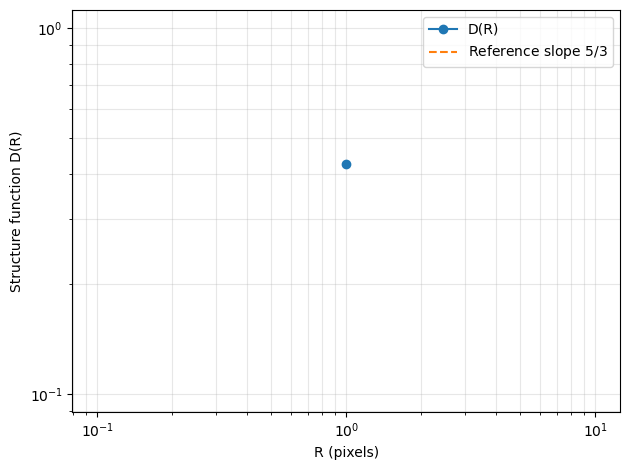

In [159]:
R = out["R"]; D = out["Dphi"]; N = out["Npairs"]

m = np.isfinite(D) & (N > 0) & (R > 0) & (D > 0)
Rv = R[m]; Dv = D[m]; Nv = N[m]

print("Используемых точек:", Rv.size)

plt.figure()
plt.loglog(Rv, Dv, marker='o', linestyle='-', label="D(R)")

slope = 5/3

# якорим в точке с максимальным Npairs (обычно стабильнее)
k = np.argmax(Nv)
R0 = Rv[k]; D0 = Dv[k]

Rref = np.array([Rv.min(), Rv.max()])
Dref = D0 * (Rref / R0) ** slope
plt.loglog(Rref, Dref, linestyle='--', label=r"Reference slope $5/3$")

plt.xlabel("R (pixels)")
plt.ylabel("Structure function D(R)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [23]:
import numpy as np

def structure_function_QU_atan2(Q, U, R_list, *,
                                min_pI=None,
                                bin_width=0.5,
                                max_pairs=None,
                                random_seed=0):
    """
    Structure function using angle difference computed via:
      Δψ = 0.5 * atan2(Q1*U2 - Q2*U1, Q1*Q2 + U1*U2)
    Then D(R) = < sin^2(Δψ) > over all pixel pairs at separation R.
    """
    Q = np.asarray(Q, dtype=float)
    U = np.asarray(U, dtype=float)
    if Q.shape != U.shape or Q.ndim != 2:
        raise ValueError("Q and U must be 2D arrays with the same shape (2D).")

    Ny, Nx = Q.shape

    pI = np.sqrt(Q*Q + U*U)
    valid = np.isfinite(Q) & np.isfinite(U) & np.isfinite(pI) & (pI > 0)
    if min_pI is not None:
        valid &= (pI >= float(min_pI))

    R_arr = np.asarray(R_list, dtype=float)
    Dphi = np.full_like(R_arr, np.nan, dtype=float)
    Npairs = np.zeros_like(R_arr, dtype=int)

    rng = np.random.default_rng(random_seed)

    def accumulate_shift(dy, dx):
        # If shift is larger than image -> no overlap
        if abs(dy) >= Ny or abs(dx) >= Nx:
            return None

        y1s = slice(max(0, dy), min(Ny, Ny + dy))
        y2s = slice(max(0, -dy), min(Ny, Ny - dy))
        x1s = slice(max(0, dx), min(Nx, Nx + dx))
        x2s = slice(max(0, -dx), min(Nx, Nx - dx))

        # Check for empty overlap (important!)
        y1len = y1s.stop - y1s.start
        y2len = y2s.stop - y2s.start
        x1len = x1s.stop - x1s.start
        x2len = x2s.stop - x2s.start
        if (y1len <= 0) or (y2len <= 0) or (x1len <= 0) or (x2len <= 0):
            return None

        # Now overlapping arrays have identical shape
        m = valid[y1s, x1s] & valid[y2s, x2s]
        if not np.any(m):
            return None

        Q1 = Q[y1s, x1s][m]; U1 = U[y1s, x1s][m]
        Q2 = Q[y2s, x2s][m]; U2 = U[y2s, x2s][m]

        num = Q1 * U2 - Q2 * U1
        den = Q1 * Q2 + U1 * U2
        dpsi = 0.5 * np.arctan2(num, den)     # radians
        contrib = np.sin(dpsi)**2
        return contrib

    for i, R in enumerate(R_arr):
        if R < 0:
            continue

        rmax = int(np.ceil(R + bin_width))
        shifts = []
        for dy in range(-rmax, rmax + 1):
            for dx in range(-rmax, rmax + 1):
                if dx == 0 and dy == 0:
                    continue
                d = np.hypot(dx, dy)
                if abs(d - R) <= bin_width:
                    shifts.append((dy, dx))

        if not shifts:
            continue

        all_contrib = []
        for dy, dx in shifts:
            contrib = accumulate_shift(dy, dx)
            if contrib is not None and contrib.size > 0:
                all_contrib.append(contrib)

        if not all_contrib:
            continue

        contrib_vec = np.concatenate(all_contrib)
        n = contrib_vec.size

        if (max_pairs is not None) and (n > max_pairs):
            idx = rng.choice(n, size=int(max_pairs), replace=False)
            contrib_vec = contrib_vec[idx]
            n = contrib_vec.size

        Dphi[i] = np.nanmean(contrib_vec)
        Npairs[i] = n

    return {"R": R_arr, "Dphi": Dphi, "Npairs": Npairs}


In [41]:
ny, nx = jcmt_data_I.squeeze().shape  # форма карты I

Qv2 = np.asarray(Qv, float)
Uv2 = np.asarray(Uv, float)

print("len(Qv), len(Uv):", Qv2.size, Uv2.size, "ny*nx:", ny*nx)

Qv2 = Qv2.reshape(ny, nx)
Uv2 = Uv2.reshape(ny, nx)


NameError: name 'jcmt_data_I' is not defined

In [28]:
Qv, Uv, _ = vgt_vectors_to_QU(vx_vgt, vy_vgt, weight=None)
R_list = np.arange(1, 101)

out2 = structure_function_QU_atan2(
    Qv, Uv, R_list,
    min_pI=None,
    bin_width=0.5,
    max_pairs=200_000
)


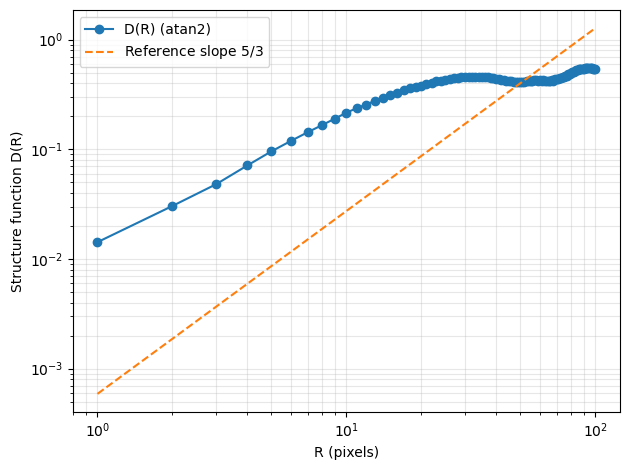

In [29]:
import numpy as np
import matplotlib.pyplot as plt

R = out2["R"]
D = out2["Dphi"]
N = out2["Npairs"]

# valid for log-log
m = np.isfinite(D) & (N > 0) & (R > 0) & (D > 0)

plt.figure()
plt.loglog(R[m], D[m], marker='o', linestyle='-', label="D(R) (atan2)")

# reference slope 5/3
slope = 5/3
k = np.where(m)[0]
k0 = k[len(k)//2]  # anchor at a middle valid index
R0 = R[k0]
D0 = D[k0]

Rref = np.array([R[m].min(), R[m].max()])
Dref = D0 * (Rref / R0) ** slope

plt.loglog(Rref, Dref, linestyle='--', label=r"Reference slope $5/3$")

plt.xlabel("R (pixels)")
plt.ylabel("Structure function D(R)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


'/Users/adelumirbaeva/Downloads'

In [223]:
dirdata_fits_jcmt = '/Users/adelumirbaeva/Dropbox/NU/NGC7538/data/fits/JCMT_pol/'


file_path_JCMT_I = dirdata_fits_jcmt +'iext_cal_beam_2d.fits'
hdul_JCMT_I = fits.open(file_path_JCMT_I)
jcmt_data_3d = hdul_JCMT_I[0].data
jcmt_data_I = np.squeeze(jcmt_data_3d)
jcmt_header_I = hdul_JCMT_I[0].header
jcmt_wcs_I = WCS(hdul_JCMT_I[0].header)

file_path_JCMT_U = dirdata_fits_jcmt+'uext_cal_beam_2d.fits'
hdul_JCMT_U = fits.open(file_path_JCMT_U)
jcmt_data_U = hdul_JCMT_U[0].data

file_path_JCMT_Q = dirdata_fits_jcmt+'qext_cal_beam_2d.fits'
hdul_JCMT_Q = fits.open(file_path_JCMT_Q)
jcmt_data_Q = hdul_JCMT_Q[0].data

phi = 0.5*np.arctan2(jcmt_data_U, jcmt_data_Q)
print('phi',phi.shape)

B_angle = phi + np.pi/2
print('B_angle',B_angle.shape)

step = 3

bx = np.cos(B_angle)
by = np.sin(B_angle)
print('bx', bx.shape)
print('by', by.shape)

x = np.arange(bx.shape[1])
y = np.arange(bx.shape[0])
print('x', x.shape)
print('y', y.shape)

phi (277, 300)
B_angle (277, 300)
bx (277, 300)
by (277, 300)
x (300,)
y (277,)


Set OBSGEO-B to    19.822839 from OBSGEO-[XYZ].
Set OBSGEO-H to     4120.022 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [245]:
# # 1D samples
Q1 = np.asarray(G111_H_clean['q_avg'], float)
U1 = np.asarray(G111_H_clean['u_avg'], float)
px, py = g111_wcs.wcs_world2pix(G111_H_clean['ra'], G111_H_clean['dec'],  1)

# pixel coords (change these column names to yours)
x = np.asarray(px, int)
y = np.asarray(py, int)

# choose map size (either from known image, or from max coords)
Ny = y.max() + 1
Nx = x.max() + 1

Qmap = np.full((Ny, Nx), np.nan, float)
Umap = np.full((Ny, Nx), np.nan, float)

# Qmap[y, x] = Q1
# Umap[y, x] = U1

R_list = np.arange(1, 80)

out = structure_function_QU_old(jcmt_data_Q, jcmt_data_U, R_list, random_seed=0)
print(type(out), out.keys())

R = out["R"]
D = out["Dphi"]
N = out["Npairs"]
out

contrib [0.6307743  0.61845484 0.66432788 ... 0.20491708 0.99752825 0.98907565]
contrib [0.02264249 0.87353985 0.6587173  ... 0.98468924 0.52870205 0.46498939]
contrib [0.71922024 0.01905113 0.36112492 ... 0.69701827 0.98502348 0.63927982]
contrib [0.08150354 0.92304045 0.96776576 ... 0.51814069 0.69152662 0.41280131]
contrib [0.08150354 0.92304045 0.96776576 ... 0.51814069 0.69152662 0.41280131]
contrib [0.71922024 0.01905113 0.36112492 ... 0.69701827 0.98502348 0.63927982]
contrib [0.02264249 0.87353985 0.6587173  ... 0.98468924 0.52870205 0.46498939]
contrib [0.6307743  0.61845484 0.66432788 ... 0.20491708 0.99752825 0.98907565]
n 445576
contrib [0.83642419 0.90705609 0.36332697 ... 0.3404954  0.24513731 0.00539429]
contrib [8.51639502e-01 9.83993661e-01 8.23205058e-04 ... 9.94983997e-01
 3.41617113e-01 7.12574538e-02]
contrib [0.01829    0.98883071 0.15740031 ... 0.99874801 0.17191635 0.98195559]
contrib [0.33332812 0.61268693 0.23902603 ... 0.3600545  0.47375629 0.37837696]
contri

{'R': array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.,
        27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38., 39.,
        40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50., 51., 52.,
        53., 54., 55., 56., 57., 58., 59., 60., 61., 62., 63., 64., 65.,
        66., 67., 68., 69., 70., 71., 72., 73., 74., 75., 76., 77., 78.,
        79.]),
 'Dphi': array([0.48644615, 0.48758115, 0.48894282, 0.49038315, 0.49203306,
        0.4938522 , 0.4947977 , 0.49583522, 0.49647841, 0.49755   ,
        0.49773527, 0.49849827, 0.49899983, 0.49934391, 0.49954651,
        0.50049347, 0.5002837 , 0.50038782, 0.50091148, 0.50058551,
        0.50104237, 0.50049562, 0.50082061, 0.50066399, 0.5009122 ,
        0.50095166, 0.50085345, 0.50069832, 0.50047589, 0.50048392,
        0.50054364, 0.50066634, 0.5001609 , 0.50034069, 0.50048338,
        0.50030074, 0.50010493, 0.50016379, 0.50008031, 0.

Используемых точек: 79


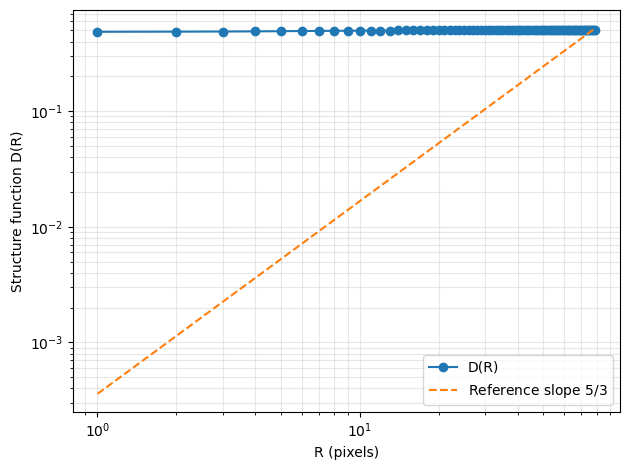

In [246]:
R = out["R"]; D = out["Dphi"]; N = out["Npairs"]

m = np.isfinite(D) & (N > 0) & (R > 0) & (D > 0)
Rv = R[m]; Dv = D[m]; Nv = N[m]

print("Используемых точек:", Rv.size)

plt.figure()
plt.loglog(Rv, Dv, marker='o', linestyle='-', label="D(R)")

slope = 5/3

# якорим в точке с максимальным Npairs (обычно стабильнее)
k = np.argmax(Nv)
R0 = Rv[k]; D0 = Dv[k]

Rref = np.array([Rv.min(), Rv.max()])
Dref = D0 * (Rref / R0) ** slope
plt.loglog(Rref, Dref, linestyle='--', label=r"Reference slope $5/3$")

plt.xlabel("R (pixels)")
plt.ylabel("Structure function D(R)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
